In [1]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import ROOT

In [2]:
file = "/eos/user/b/bbapi/MC_contacts/9c73d09e-d2f0-4ccf-86a6-8f4a28e9154d.root"
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

In [3]:
gen = events.GenPart

In [9]:
Wplus = gen[(gen.pdgId == 24) & (gen.status == 62)]
Wminus = gen[(gen.pdgId == -24) & (gen.status == 62)]

In [10]:
Wplus.pt*1

<Array [[], [], [139], ..., [44.6], [], []] type='17000 * var * float32[par...'>

In [11]:
Wminus.pt*1

<Array [[55.9], [38.6], [], ..., [234], [267]] type='17000 * var * float32[...'>

In [ ]:
gen = events.GenPart
Wplus = gen[(gen.pdgId == 24) & (gen.status == 62)]
Wminus = gen[(gen.pdgId == -24) & (gen.status == 62)]
ak.sum(Wplus.pt)/ak.sum(Wminus.pt)

1.7004441

In [3]:
events.fields

['GenVisTau',
 'Photon',
 'LHE',
 'MC',
 'SoftActivityJet',
 'SubJet',
 'HTXS',
 'GenVtx',
 'RawPFMET',
 'FatJetPFCand',
 'SoftActivityJetHT2',
 'luminosityBlock',
 'L1simulation',
 'FsrPhoton',
 'L1Reco',
 'SoftActivityJetNjets5',
 'Rho',
 'orbitNumber',
 'SoftActivityJetHT10',
 'event',
 'SV',
 'Tau',
 'TrkMET',
 'TrackGenJetAK4',
 'genTtbarId',
 'Electron',
 'Jet',
 'PFMET',
 'Dataset',
 'PFCand',
 'Flag',
 'HLT',
 'L1',
 'SoftActivityJetNjets2',
 'BeamSpot',
 'Muon',
 'GenMET',
 'DeepMETResolutionTune',
 'TrigObj',
 'GenProton',
 'LHEScaleWeight',
 'DST',
 'GenJetAK8',
 'IsoTrack',
 'bunchCrossing',
 'PuppiMET',
 'SoftActivityJetHT5',
 'LHEWeight',
 'FatJet',
 'GenDressedLepton',
 'OtherPV',
 'CorrT1METJet',
 'Generator',
 'PSWeight',
 'GenPart',
 'FiducialMET',
 'CaloMET',
 'LowPtElectron',
 'SubGenJetAK8',
 'GenJet',
 'Pileup',
 'HLTriggerFirstPath',
 'TauSpinner',
 'genWeight',
 'HLTriggerFinalPath',
 'RawPuppiMET',
 'DeepMETResponseTune',
 'boostedTau',
 'LHEReweightingWeight',

In [4]:
# ------------------------------------------
# Function: Plot n_object (multiplicity)
# ------------------------------------------
def plot_n_object(obj_array, title="nObjects", bins=10, xmin=0, xmax=10, outname="nobj.png"):
    """
    obj_array: awkward array (e.g. events.Photon)
    """
    Plot_dir = "/eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/"

    # Get number of objects per event
    n_obj = ak.num(obj_array)

    # Convert to numpy
    n_obj_np = ak.to_numpy(n_obj)

    # Create histogram
    hist = ROOT.TH1F("", "", bins, xmin, xmax)

    for val in n_obj_np:
        hist.Fill(val)

    # Draw
    canvas = ROOT.TCanvas("c_nobj", "", 800, 600)

    hist.GetXaxis().SetTitle(title)
    hist.GetYaxis().SetTitle("Events")

    hist.SetLineWidth(2)
    hist.Draw("HIST")

    # ---- Move stat box ----
    canvas.Update()  # REQUIRED before accessing stat box
    stat = hist.GetListOfFunctions().FindObject("stats")

    if stat:
        stat.SetX1NDC(0.65)
        stat.SetX2NDC(0.88)
        stat.SetY1NDC(0.70)
        stat.SetY2NDC(0.88)

    canvas.Modified()
    canvas.Update()

    latex = ROOT.TLatex()
    latex.SetNDC(True)          # normalized coordinates (0–1)
    latex.SetTextFont(42)
    latex.SetTextSize(0.035)

    latex.DrawLatex(0.52, 0.40, "WH-2024M30")

    canvas.SaveAs(Plot_dir + outname)

    return hist


# ------------------------------------------
# Function: Plot 1D variable
# ------------------------------------------
def plot_1d(var_array, title="Variable", bins=50, xmin=0, xmax=100, outname="var.png"):
    """
    var_array: awkward array (flattenable), e.g. photons.pt
    """
    Plot_dir = "/eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/"

    # Flatten (important!)
    flat = ak.flatten(var_array)

    # Convert to numpy
    flat_np = ak.to_numpy(flat)

    # Histogram
    hist = ROOT.TH1F("", "", bins, xmin, xmax)

    for val in flat_np:
        hist.Fill(val)

    # Draw
    canvas = ROOT.TCanvas("c_var", "", 800, 600)

    hist.GetXaxis().SetTitle(title)
    hist.GetYaxis().SetTitle("Entries")

    hist.SetLineWidth(2)
    hist.Draw("HIST")

    # ---- Move stat box ----
    canvas.Update()  # REQUIRED before accessing stat box
    stat = hist.GetListOfFunctions().FindObject("stats")

    if stat:
        stat.SetX1NDC(0.65)
        stat.SetX2NDC(0.88)
        stat.SetY1NDC(0.70)
        stat.SetY2NDC(0.88)

    canvas.Modified()
    canvas.Update()

    latex = ROOT.TLatex()
    latex.SetNDC(True)          # normalized coordinates (0–1)
    latex.SetTextFont(42)
    latex.SetTextSize(0.035)

    latex.DrawLatex(0.52, 0.40, "WH-2024M30")

    canvas.SaveAs(Plot_dir + outname)

    return hist

In [5]:
plot_n_object(events.Electron[ak.num(events.Electron)>0], title="Number of electrons before preselecton", outname='NElectrons_before_preselection.png')

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/NElectrons_before_preselection.png has been created


In [3]:
events.fields

['GenDressedLepton',
 'HLT',
 'genWeight',
 'OtherPV',
 'SoftActivityJetHT10',
 'HLTriggerFirstPath',
 'LHEPart',
 'Tau',
 'L1',
 'SV',
 'LHEReweightingWeight',
 'TrkMET',
 'Rho',
 'event',
 'PVBS',
 'SoftActivityJetHT',
 'genTtbarId',
 'CaloMET',
 'GenPart',
 'CorrT1METJet',
 'LHEPdfWeight',
 'DST',
 'Dataset',
 'luminosityBlock',
 'GenIsolatedPhoton',
 'GenJetAK8',
 'Muon',
 'bunchCrossing',
 'LowPtElectron',
 'SoftActivityJet',
 'RawPFMET',
 'orbitNumber',
 'GenVisTau',
 'TrigObj',
 'IsoTrack',
 'FiducialMET',
 'Jet',
 'HLTriggerFinalPath',
 'GenMET',
 'DeepMETResponseTune',
 'FatJet',
 'TrackGenJetAK4',
 'GenJet',
 'BeamSpot',
 'SubGenJetAK8',
 'SoftActivityJetNjets2',
 'FatJetPFCand',
 'RawPuppiMET',
 'Generator',
 'GenVtx',
 'boostedTau',
 'TauProd',
 'Electron',
 'HTXS',
 'SoftActivityJetNjets5',
 'SoftActivityJetHT2',
 'FsrPhoton',
 'run',
 'Photon',
 'Pileup',
 'PFMET',
 'MC',
 'PV',
 'SoftActivityJetHT5',
 'LHE',
 'PSWeight',
 'L1simulation',
 'DeepMETResolutionTune',
 'Puppi

In [4]:
from higgs_dna.selections.object_selections import delta_r_mask

In [5]:
def select_electrons(
    electrons: ak.highlevel.Array
    # diphotons
) -> ak.highlevel.Array:
    pt_cut = electrons.pt > 30

    eta_cut = abs(electrons.eta) < 2.5

    id_cut = electrons.mvaIso_WP80

    # dr_cut_lead_pho_ele = delta_r_mask(electrons, diphotons.pho_lead, 0.2)
    # dr_cut_sublead_pho_ele = delta_r_mask(electrons, diphotons.pho_sublead, 0.2)

    return pt_cut & eta_cut & id_cut 


def select_muons(
    muons: ak.highlevel.Array
    # diphotons: ak.highlevel.Array
) -> ak.highlevel.Array:
    pt_cut = muons.pt > 24

    eta_cut = abs(muons.eta) < 2.4

    id_cut = muons.mediumId

    iso_cut = muons.pfIsoId >= 3

    global_cut = muons.isGlobal

    # dr_phoLead_cut = delta_r_mask(muons, diphotons.pho_lead, self.muon_photon_min_dr)
    # dr_phoSublead_cut = delta_r_mask(muons, diphotons.pho_sublead, self.muon_photon_min_dr)


    return pt_cut & eta_cut & id_cut & iso_cut & global_cut

In [37]:
def select_jets(
    jets: ak.highlevel.Array,
    diphotons, 
    electrons,
    muons
) -> ak.highlevel.Array:

    jetId_cut = jets.jetId >= 2

    pt_cut = jets.pt > 20
    eta_cut = abs(jets.eta) < 4.7

    dr_cut_lead_pho_jet = delta_r_mask(jets, diphotons.pho_lead, 0.4)
    dr_cut_sublead_pho_jet = delta_r_mask(jets, diphotons.pho_sublead, 0.4)
    dr_cut_ele = delta_r_mask(jets, electrons, 0.4)
    dr_cut_mu = delta_r_mask(jets, muons, 0.4)

    return (
        (jetId_cut)
        & (pt_cut)
        & (eta_cut)
        & (dr_cut_ele)
        & (dr_cut_mu)
        & (dr_cut_lead_pho_jet)
        & (dr_cut_sublead_pho_jet)
    )

In [26]:
def photon_preselection(
    photons: ak.Array,
    electrons, 
    muons
    # jets
    # jets
) -> ak.Array:
    """
    Apply preselection cuts to photons.
    Note that these selections are applied on each photon, it is not based on the diphoton pair.
    """
    # hlt-mimicking cuts
    # print(events.fields)
    # rho = events.Rho.fixedGridRhoAll * ak.ones_like(photons.pt)
    # print(photons.fields)
    abs_eta = np.abs(photons.eta)
    valid_eta = (abs_eta <= 2.5) & ~((abs_eta >= 1.442) & (abs_eta <= 1.566))

    dr_cut = delta_r_mask(photons, electrons, 0.2)
    dr_cut_muon = delta_r_mask(photons, muons, 0.2)
    # dr_cut_jet = delta_r_mask(photons, jets, 0.4)

        # quadratic EA corrections in Run3 : https://indico.cern.ch/event/1204277/contributions/5064356/attachments/2538496/4369369/CutBasedPhotonID_20221031.pdf
    return photons[
        (photons.pt > 15)
        & valid_eta
        & dr_cut
        & dr_cut_muon
        # & dr_cut_jet
        # & (photons.mvaID > self.min_mvaid)
        &(ak.where(photons.isScEtaEB, photons.mvaID > 0.0439603, photons.mvaID > -0.249526))
    ]

In [11]:
ak.num(events.Electron)

<Array [1, 2, 0, 0, 1, 0, 0, 1, ..., 2, 0, 1, 1, 3, 2, 0] type='16000 * int64'>

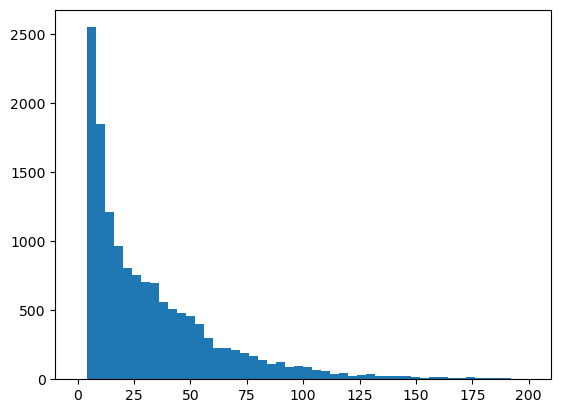

In [13]:
plt.hist(ak.flatten(events.Electron.pt), bins=50, range=(0, 200));

In [196]:
plot_1d(events.Electron.pt, title="Electron pT before preselecton", xmax=200, outname='Electron_pt_before_preselection.png')

Info in <TCanvas::Print>: png file plots/Electron_pt_before_preselection.png has been created


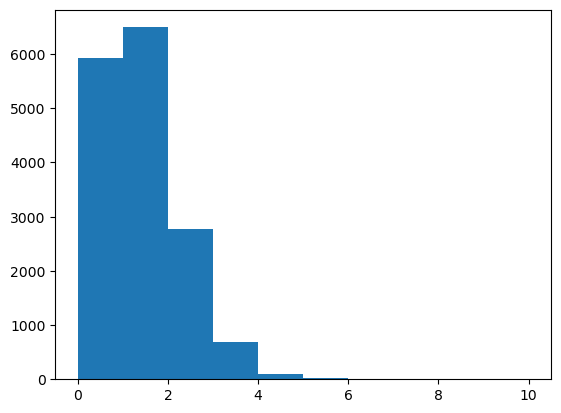

In [14]:
plt.hist(ak.num(events.Electron), bins=10, range=(0, 10));

In [197]:
plot_n_object(events.Electron, title="Number of electrons before preselecton", outname='NElectrons_before_preselection.png')

Info in <TCanvas::Print>: png file plots/NElectrons_before_preselection.png has been created


In [18]:
selected_electrons = events.Electron[select_electrons(events.Electron)]

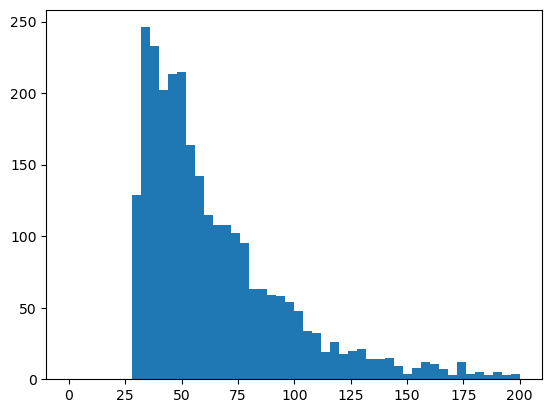

In [19]:
plt.hist(ak.flatten(selected_electrons.pt), bins=50, range=(0, 200));

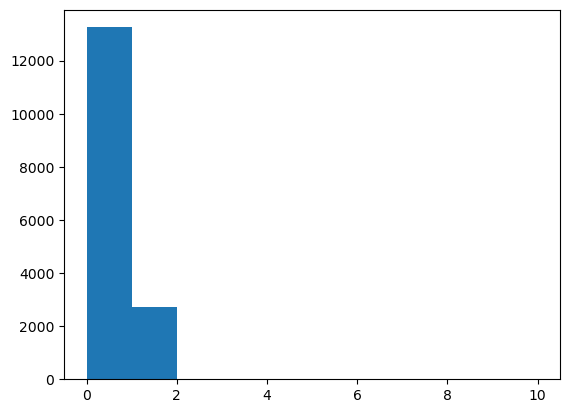

In [20]:
plt.hist(ak.num(selected_electrons), bins=10, range=(0, 10));

In [8]:
from higgs_dna.selections.diphoton_selections import build_diphoton_candidates

In [9]:
photons = events.Photon

photons["mass"] = ak.zeros_like(photons.pt)  
photons["charge"] = ak.zeros_like(photons.pt)

photons = ak.with_name(photons, "PtEtaPhiMCandidate")
# diphotons = build_diphoton_candidates(photons, 15)

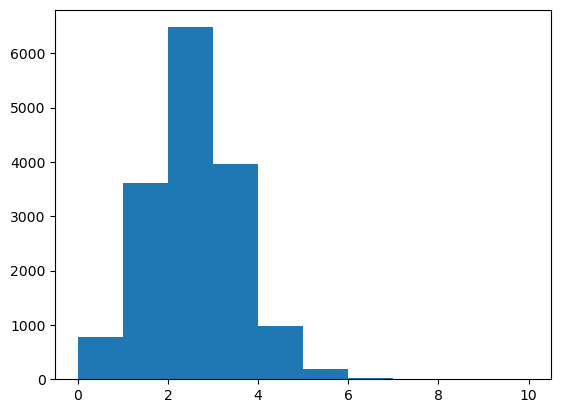

In [31]:
plt.hist(ak.num(photons), bins=10, range=(0, 10));

In [66]:
dr_ele_pho_lead = delta_r_mask(selected_electrons, diphotons.pho_lead, 0.2)
dr_ele_pho_sublead = delta_r_mask(selected_electrons, diphotons.pho_sublead, 0.2)

In [67]:
len(selected_electrons[ak.num(selected_electrons)>0])

2744

In [68]:
ak.sum(dr_ele_pho_lead & dr_ele_pho_sublead)

145

In [69]:
selected_photons = photon_preselection(photons)

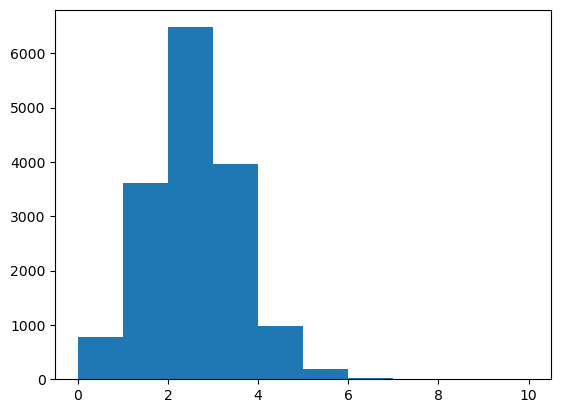

In [62]:
plt.hist(ak.num(photons), bins=10, range=(0, 10));

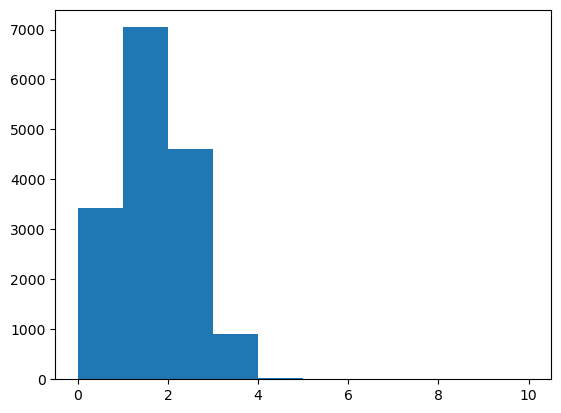

In [63]:
plt.hist(ak.num(selected_photons.pt), bins=10, range=(0, 10));

In [64]:
selected_diphotons = build_diphoton_candidates(selected_photons, 15)

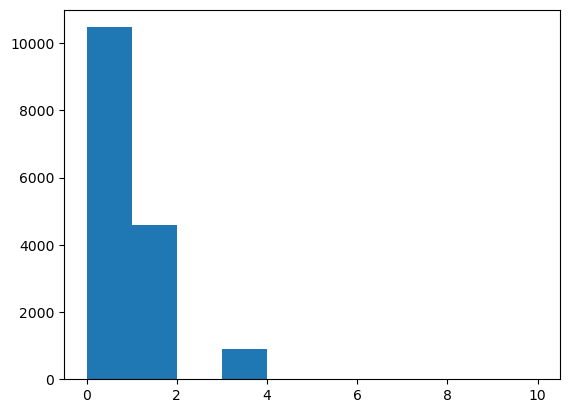

In [65]:
plt.hist(ak.num(selected_diphotons.pho_lead.pt), bins=10, range=(0, 10));

In [71]:
dr_ele_pho_lead = delta_r_mask(selected_electrons, selected_diphotons.pho_lead, 0.2)
dr_ele_pho_sublead = delta_r_mask(selected_electrons, selected_diphotons.pho_sublead, 0.2)

In [72]:
ak.sum(dr_ele_pho_lead & dr_ele_pho_sublead)

939

In [112]:
electrons = events.Electron
# sel_ele1 = electrons[select_electrons(electrons, diphotons)]
# sel_ele2 = electrons[select_electrons(electrons, selected_diphotons)]

In [ ]:
# sel_ele1[ak.num(sel_ele1)>0].pt

<Array [[61.6], [48.1], ..., [37.6], [139]] type='145 * var * float32[param...'>

In [ ]:
# sel_ele2[ak.num(sel_ele2)>0].pt

<Array [[90.3], [41.7], ..., [49.2], [168]] type='935 * var * float32[param...'>

In [89]:
len(selected_photons[ak.num(selected_photons.pt)>0])

12001

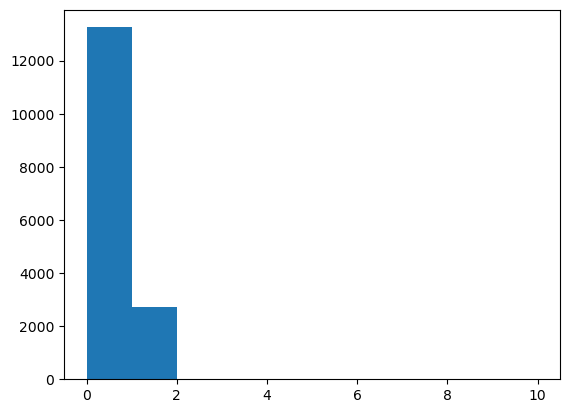

In [91]:
plt.hist(ak.num(selected_electrons), bins=10, range=(0,10));

In [93]:
at_least_two_photons = ak.num(selected_photons)>=2
one_ele = ak.num(selected_electrons) == 1

In [94]:
ak.sum(at_least_two_photons & one_ele)

683

In [101]:
jets = events.Jet

In [110]:
from higgs_dna.tools.jetID import add_jetId
Jet_id = add_jetId(jets, 15, "2024", flattenUnflatten=True)
events["Jet"] = ak.with_field(jets, Jet_id, "jetId")
selected_jets = jets[select_jets(jets)]

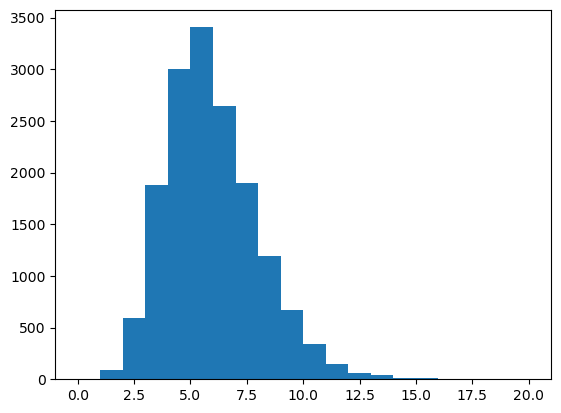

In [104]:
plt.hist(ak.num(jets), bins=20, range=(0,20));

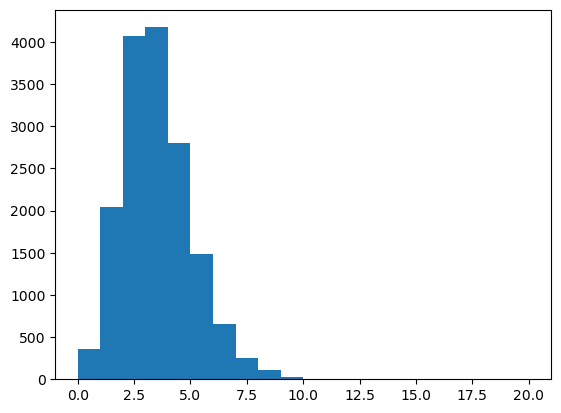

In [105]:
plt.hist(ak.num(selected_jets), bins=20, range=(0,20));

In [10]:
def delta_r_manual(obj1, obj2):
    deta = obj1.eta[:, None] - obj2.eta
    dphi = np.abs(obj1.phi[:, None] - obj2.phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

In [38]:
electrons = events.Electron

from higgs_dna.tools.jetID import add_jetId
jets = events.Jet
Jet_id = add_jetId(jets, 15, "2024", flattenUnflatten=True)
events["Jet"] = ak.with_field(jets, Jet_id, "jetId")

selected_electrons = electrons[select_electrons(electrons)]

selected_photons = photon_preselection(photons, selected_electrons, selected_muons)

selected_diphotons = build_diphoton_candidates(selected_photons, 15)

selected_jets = jets[select_jets(jets, selected_diphotons, selected_electrons, selected_muons)]

selected_bjets = selected_jets[selected_jets.btagUParTAK4B>0.1272]

In [14]:
len(selected_photons[ak.num(selected_photons)>0])

12001

In [39]:
at_least_two_photons = ak.num(selected_photons)>=2
one_ele = ak.num(selected_electrons) == 1
at_least_two_bjets = ak.num(selected_bjets) >= 2
at_least_one_bjets = ak.num(selected_bjets) >= 1
event_mask = at_least_two_photons & one_ele & at_least_two_bjets

In [15]:
ak.sum(event_mask)

81

In [16]:
dr_mask = delta_r_mask(selected_electrons, photons, 0.2)
dr_mask = dr_mask[ak.num(dr_mask)>0]

In [17]:
dr_mask

<Array [[False], [False], ..., [False], [False]] type='2744 * var * bool'>

In [34]:
dr = delta_r_manual(selected_electrons, photons)

In [17]:
dr

<Array [[[]], [[1.19], ...], ..., [[], [], []]] type='17000 * var * var * f...'>

In [35]:
dr_goods = delta_r_manual(selected_electrons, selected_photons)

In [19]:
dr_goods

<Array [[[]], [[1.19]], ..., [[]], [[], []]] type='17000 * var * var * floa...'>

In [27]:
dr_flattened = ak.flatten(dr)
dr_ne = dr_flattened[ak.num(dr_flattened)>0]
dr_goods_flattened = ak.flatten(dr_goods)
dr_goods_ne = dr_goods_flattened[ak.num(dr_goods_flattened)>0] 

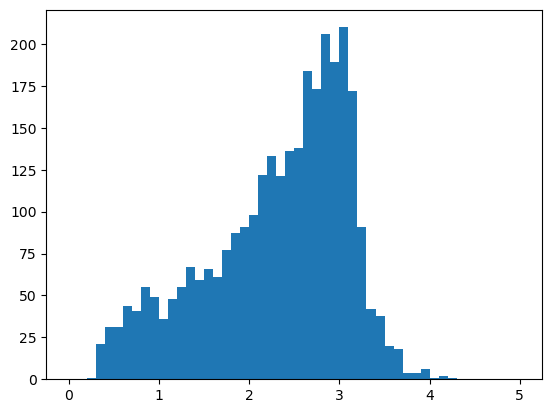

In [20]:
plt.hist(ak.flatten(ak.flatten(dr_goods)), bins=50, range=(0,5));

In [71]:
mask = ak.any(dr < 0.2, axis=-1)

In [72]:
mask

<Array [[False], [...], ..., [False, False, False]] type='17000 * var * bool'>

In [73]:
photons[mask].pt

<Array [[], [30.2], [], [], ..., [], [], []] type='17000 * var * float32[pa...'>

In [74]:
close_photons = photons[mask]

In [75]:
gen = events.GenPart

In [116]:
close_photon_matched_gen = gen[close_photons.genPartIdx]

In [117]:
close_photon_matched_gen[ak.num(close_photon_matched_gen)>0].pdgId

<Array [[11], [-11], [-11], ..., [-11], [-11]] type='2996 * var * int32[par...'>

In [120]:
mother_close_photon_matched_gen = gen[close_photon_matched_gen.genPartIdxMother]

In [78]:
mother_close_photon_from_electron = mother_close_photon[abs(mother_close_photon.pdgId) == 11]

In [79]:
mother_close_photon_from_electron_mother = gen[mother_close_photon_from_electron.genPartIdxMother].pdgId

In [80]:
mother_close_photon_from_electron_mother_clean = mother_close_photon_from_electron_mother[ak.num(mother_close_photon_from_electron_mother)>0]

In [81]:
mother_close_photon_from_electron_mother_clean

<Array [[-24], [24], [24], ..., [-24], [24]] type='1218 * var * int32[param...'>

In [83]:
mother_close_photon_clean = mother_close_photon[ak.num(mother_close_photon)>0]

In [33]:
np.unique(ak.flatten(mother_close_photon_clean))

<Array [-531, -521, -511, -433, ..., 423, 431, 521, 531] type='26 * int32'>

In [86]:
mother_close_photon_clean.pdgId

<Array [[11], [24], [-11], ..., [24], [-11]] type='2996 * var * int32[param...'>

In [137]:
Gen.pdgId

<Array [[], [11], [], [], ..., [], [], [], []] type='17000 * var * int32[pa...'>

In [141]:
from collections import Counter
from particle import Particle

# Flatten PDG IDs
# pdg_ids = ak.to_numpy(ak.flatten(mother_close_photon_matched_gen[ak.num(mother_close_photon_matched_gen) > 0].pdgId))
# pdg_ids = ak.to_numpy(ak.flatten(close_photon_matched_gen[ak.num(close_photon_matched_gen) > 0].pdgId))

Gen = mother_close_photon_matched_gen

pdg = Gen.pdgId
mother_idx = Gen.genPartIdxMother

# mask for electrons
is_ele = (abs(pdg) == 11)

# mask for valid mother
has_mother = mother_idx >= 0

pdg = Gen.pdgId
mother_idx = Gen.genPartIdxMother

is_ele = (abs(pdg) == 11)
has_mother = mother_idx >= 0

# fetch mothers from FULL collection
mother_pdg = ak.where(
    has_mother,
    gen.pdgId[mother_idx],
    pdg
)

# replace only electrons
new_pdg = ak.where(is_ele & has_mother, mother_pdg, pdg)

# Count frequencies
counter = Counter(ak.flatten(new_pdg))

# Convert to names
labels = []
counts = []

for pdg, count in sorted(counter.items()):
    try:
        name = Particle.from_pdgid(pdg).name
    except:
        name = str(pdg)  # fallback if unknown
    
    labels.append(name)
    counts.append(count)

In [145]:
pdg_ids = ak.to_numpy(ak.flatten(close_photon_matched_gen[ak.num(close_photon_matched_gen) > 0].pdgId))

# Optional: take absolute values (merge particle/antiparticle)
pdg_ids = pdg_ids

# Count frequencies
counter = Counter(pdg_ids)

# Convert to names
labels = []
counts = []

for pdg, count in sorted(counter.items()):
    try:
        name = Particle.from_pdgid(pdg).name
    except:
        name = str(pdg)  # fallback if unknown
    
    labels.append(name)
    counts.append(count)

In [146]:
n = len(labels)

ROOT.gStyle.SetOptStat(0)  # Show entries and mean in stat box

# hist = ROOT.TH1F("h_pdg", ";Mother of matched gen particle to close photon;Count", n, 0, n)
hist = ROOT.TH1F("h_pdg", ";Matched gen particle to close photon;Count", n, 0, n)

for i, (label, count) in enumerate(zip(labels, counts), start=1):
    hist.SetBinContent(i, count)
    hist.GetXaxis().SetBinLabel(i, label)

# Styling
hist.LabelsOption("v")  # vertical labels

c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.15)  # increase bottom margin for labels
hist.Draw("HIST")
hist.GetXaxis().SetTitleOffset(2.4)

# c.SaveAs("/eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/pdg_frequency_mother_matched_gen_close_photon.png")
c.SaveAs("/eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/pdg_frequency_matched_gen_close_photon.png")

Warning in <TROOT::Append>: Replacing existing TH1: h_pdg (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/pdg_frequency_matched_gen_close_photon.png has been created


In [68]:
mask_per_photon = ~ak.any(dr, axis=-1)

In [69]:
mask_per_photon

<Array [[True, True], [True, ...], ..., [True, True]] type='16000 * var * bool'>

In [73]:
ak.flatten(dr<0.2)

<Array [[], [], [], [], ..., [], [], []] type='33441 * var * bool[parameter...'>

In [53]:
ak.flatten(ak.flatten(dr))

<Array [2.74, 0.00195, 2.14, ..., 0.008, 3.17] type='7763 * float32[paramet...'>

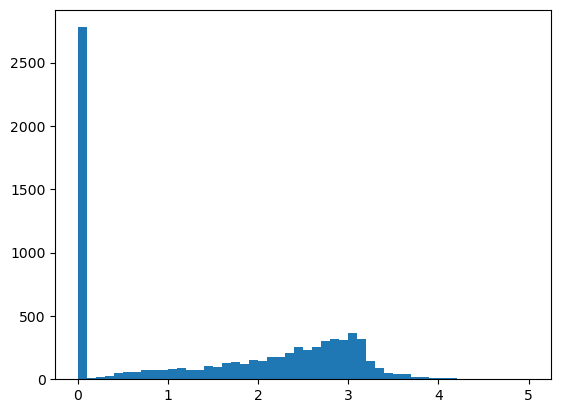

In [54]:
plt.hist(ak.flatten(ak.flatten(dr)), bins=50, range=(0,5));

In [ ]:
ak.sum()

2772

In [41]:
len(selected_electrons[ak.num(selected_electrons)>0])

2744

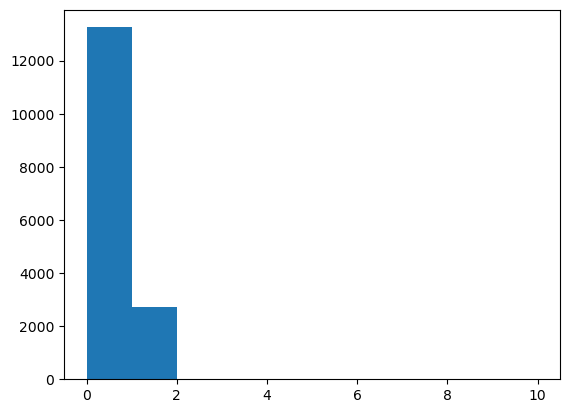

In [42]:
plt.hist(ak.num(selected_electrons), bins=10, range=(0,10));

In [22]:
ak.sum(one_ele)

931

In [23]:
ak.sum(at_least_two_photons)

5528

In [24]:
ak.sum(at_least_two_bjets)

1871

In [25]:
event_mask_pho_ele =  at_least_two_photons & one_ele 

In [26]:
event_mask_pho_jets = at_least_two_photons & at_least_two_bjets

In [27]:
ak.sum(event_mask_pho_ele)

89

In [28]:
ak.sum(event_mask_pho_jets)

556

In [37]:
ak.sum(event_mask)

58

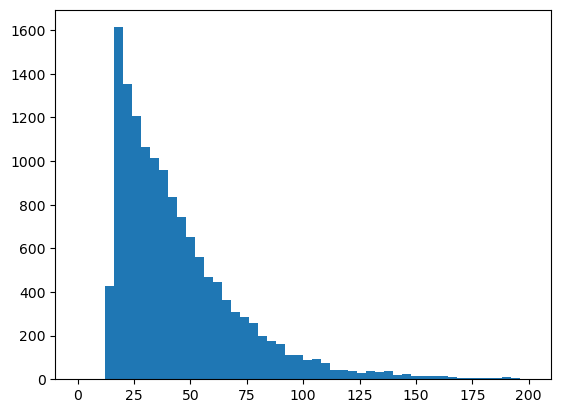

In [134]:
plt.hist(ak.flatten(selected_photons.pt), bins = 50, range=(0, 200));

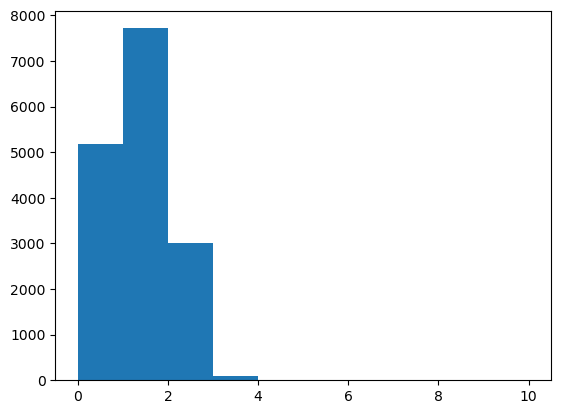

In [152]:
plt.hist(ak.num(selected_photons), bins = 10, range=(0,10));

In [164]:
final_selected_photons = selected_photons[event_mask]
pixel_seeded_photons = final_selected_photons[~final_selected_photons.pixelSeed]
ele_veto_photons = pixel_seeded_photons[pixel_seeded_photons.electronVeto == 1]

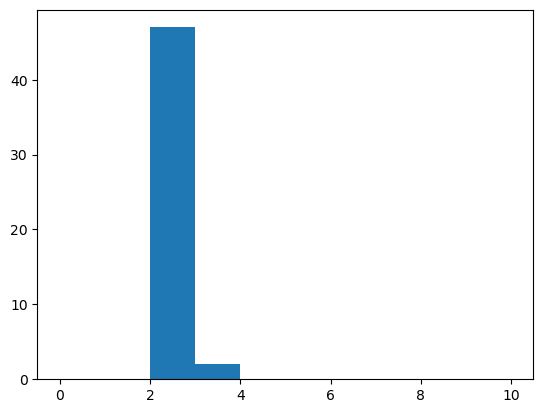

In [154]:
plt.hist(ak.num(final_selected_photons), bins = 10, range=(0,10));

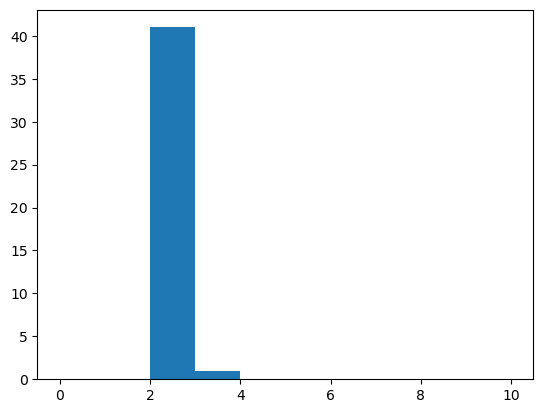

In [166]:
plt.hist(ak.num(pixel_seeded_photons), bins = 10, range=(0,10));

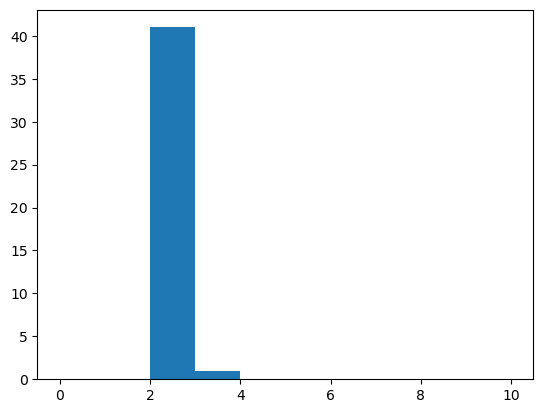

In [165]:
plt.hist(ak.num(ele_veto_photons), bins = 10, range=(0,10));

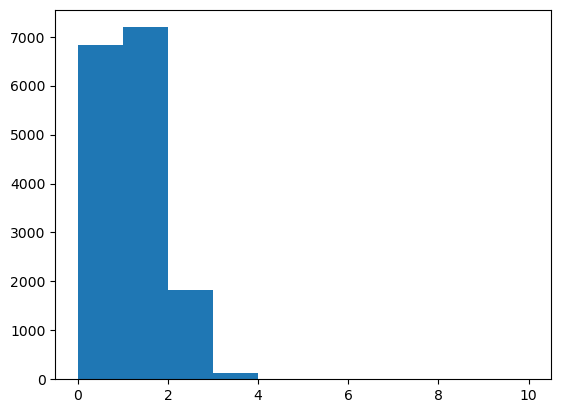

In [167]:
plt.hist(ak.num(selected_bjets), bins = 10, range=(0,10));

In [156]:
len(pixel_seeded_photons[ak.num(pixel_seeded_photons)>=2])

42

In [162]:
at_least_two_pixel_seeded_photons = ak.num(selected_photons[~selected_photons.pixelSeed])>=2
one_ele = ak.num(selected_electrons) == 1
at_least_two_bjets = ak.num(selected_bjets) >= 2
event_mask = at_least_two_pixel_seeded_photons & one_ele & at_least_two_bjets

In [163]:
ak.sum(event_mask)

42

In [31]:
selected_photons_after_pixel_seed = selected_photons[~selected_photons.pixelSeed]
selected_photons_after_pixel_seed_eveto = selected_photons_after_pixel_seed[selected_photons_after_pixel_seed.electronVeto == 1]

In [32]:
selected_photons_after_eveto = selected_photons[selected_photons.electronVeto == 1]
selected_photons_after_eveto_pixelSeed = selected_photons_after_eveto[~selected_photons_after_eveto.pixelSeed]

In [149]:
PDG = events.GenPart.pdgId

n_ep = ak.sum(PDG == -11)
n_em = ak.sum(PDG == 11)

print(n_ep / n_em)

1.0775422065174716


In [36]:
plot_n_object(events.Electron[ak.num(events.Electron)>0], title="Number of electrons before preselecton", outname='NElectrons_before_preselection.png')
plot_1d(events.Electron[ak.num(events.Electron)>0].pt, title="Electron pT before preselecton", xmax=200, outname='Electron_pt_before_preselection.png')
plot_n_object(events.Photon[ak.num(events.Photon)>0], title="Number of photons before preselecton", outname='NPhotons_before_preselection.png')
plot_1d(events.Photon[ak.num(events.Photon)>0].pt, title="Photon pT before preselecton", xmax=200, outname='Photon_pt_before_preselection.png')
plot_n_object(selected_electrons[ak.num(selected_electrons)>0], title="Number of electrons after preselecton", outname='NElectrons_after_preselection.png')
plot_1d(selected_electrons[ak.num(selected_electrons)>0].pt, title="Electron pT after preselecton", xmax=200, outname='Electron_pt_after_preselection.png')
plot_n_object(selected_photons[ak.num(selected_photons)>0], title="Number of photons after preselecton", outname='NPhotons_after_preselection.png')
plot_1d(selected_photons[ak.num(selected_photons)>0].pt, title="Photon pT after preselecton", xmax=200, outname='Photon_pt_after_preselection.png')
plot_n_object(selected_bjets[ak.num(selected_bjets)>0], title="Number of bjets after preselecton", outname='NbJets_after_preselection.png')
plot_1d(selected_bjets[ak.num(selected_bjets)>0].pt, title="bjets pT after preselecton", xmax=200, outname='bJets_pt_after_preselection.png')
plot_n_object(selected_photons_after_pixel_seed[ak.num(selected_photons_after_pixel_seed)>0], title="Number of photons after preselecton+pixelSeed", outname='NPhotons_after_preselection_pixelSeed.png')
plot_1d(selected_photons_after_pixel_seed[ak.num(selected_photons_after_pixel_seed)>0].pt, title="Photon pT after preselecton+pixelSeed", xmax=200, outname='Photon_pt_after_preselection_pixelSeed.png')
plot_n_object(selected_photons_after_pixel_seed_eveto[ak.num(selected_photons_after_pixel_seed_eveto)>0], title="Number of photons after preselecton+pixelSeed+eVeto", outname='NPhotons_after_preselection_pixelSeed_eVeto.png')
plot_1d(selected_photons_after_pixel_seed_eveto[ak.num(selected_photons_after_pixel_seed_eveto)>0].pt, title="Photon pT after preselecton+pixelSeed+eVeto", xmax=200, outname='Photon_pt_after_preselection_pixelSeed_eVeto.png')
plot_1d(ak.flatten(dr), title="Delta R between selected electrons and photons", bins=50, xmax=5, outname='DeltaR_electron_photon.png')
plot_1d(ak.flatten(dr_goods), title="Delta R between selected electrons and selected photons", bins=50, xmax=5, outname='DeltaR_electron_photon_good_pairs.png')
plot_n_object(selected_photons_after_eveto[ak.num(selected_photons_after_eveto)>0], title="Number of photons after preselecton+electronVeto", outname='NPhotons_after_electronVeto.png')
plot_1d(selected_photons_after_eveto[ak.num(selected_photons_after_eveto)>0].pt, title="Photon pT after preselecton+electronVeto", xmax=200, outname='Photon_pt_after_preselection_electronVeto.png')
plot_n_object(selected_photons_after_eveto_pixelSeed[ak.num(selected_photons_after_eveto_pixelSeed)>0], title="Number of photons after preselecton+eVeto+pixelSeed", outname='NPhotons_after_preselection_eveto_pixelSeed.png')
plot_1d(selected_photons_after_eveto_pixelSeed[ak.num(selected_photons_after_eveto_pixelSeed)>0].pt, title="Photon pT after preselecton+eVeto+pixelSeed", xmax=200, outname='Photon_pt_after_preselection_eVeto_pixelSeed.png')

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/NElectrons_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/Electron_pt_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/NPhotons_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/Photon_pt_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/NElectrons_after_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/Electron_pt_after_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Anal

# Starting Muon case

In [14]:
muons = events.Muon
selected_muons = muons[select_muons(muons)]

In [15]:
dr_mu = delta_r_manual(selected_muons, photons)
dr_mu_goods = delta_r_manual(selected_muons, selected_photons)

In [38]:
dr_mu

<Array [[[]], [[], ..., []], ..., [[], [], []]] type='17000 * var * var * f...'>

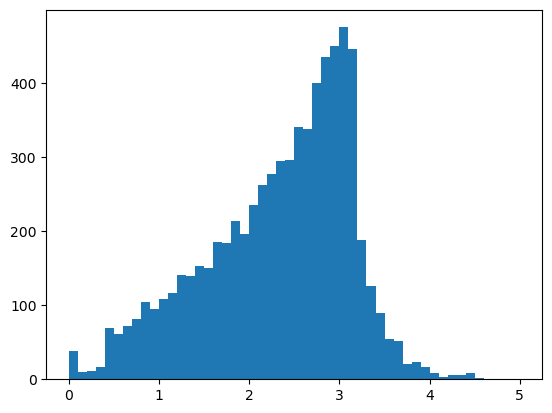

In [39]:
plt.hist(ak.flatten(ak.flatten(dr_mu)), bins=50, range=(0,5));

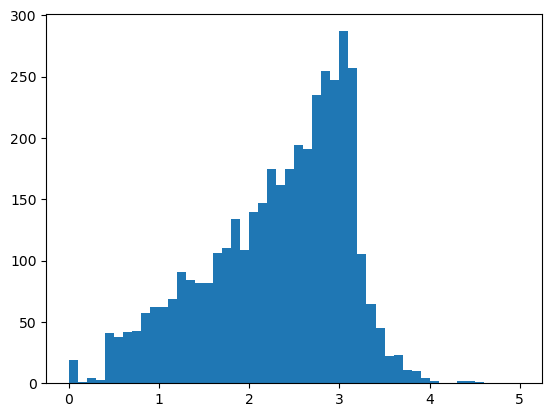

In [41]:
plt.hist(ak.flatten(ak.flatten(dr_mu_goods)), bins=50, range=(0,5));

In [17]:
plot_n_object(events.Muon[ak.num(events.Muon)>0], title="Number of muons before preselecton", outname='NMuons_before_preselection.png')
plot_1d(events.Muon[ak.num(events.Muon)>0].pt, title="Muon pT before preselecton", xmax=200, outname='Muon_pt_before_preselection.png')
plot_n_object(selected_muons[ak.num(selected_muons)>0], title="Number of muons after preselecton", outname='NMuons_after_preselection.png')
plot_1d(selected_muons[ak.num(selected_muons)>0].pt, title="Muon pT after preselecton", xmax=200, outname='Muon_pt_after_preselection.png')
plot_1d(ak.flatten(dr_mu), title="Delta R between selected muons and photons", bins=50, xmax=5, outname='DeltaR_muon_photon.png')
plot_1d(ak.flatten(dr_mu_goods), title="Delta R between selected muons and selected photons", bins=50, xmax=5, outname='DeltaR_muon_photon_good_pairs.png')

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/NMuons_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/Muon_pt_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/NMuons_after_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/Muon_pt_after_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/DeltaR_muon_photon.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/DeltaR_muon_photon_good_pairs.png has been created


# Starting the Jet case

In [40]:
dr_jets = delta_r_manual(selected_jets, photons)
dr_jets_good = delta_r_manual(selected_jets, selected_photons)
dr_jets_good_photon = delta_r_manual(selected_photons, selected_jets)

In [41]:
bJets = events.Jet[events.Jet.btagUParTAK4B>0.1272]

In [42]:
plot_n_object(events.Jet[ak.num(events.Jet)>0], title="Number of jets before preselecton", outname='NJets_before_preselection.png')
plot_n_object(bJets[ak.num(bJets)>0], title="Number of bJets before preselecton", outname='NbJets_before_preselection.png')
plot_1d(events.Jet[ak.num(events.Jet)>0].pt, title="Jets pT before preselecton", xmax=200, outname='Jet_pt_before_preselection.png')
plot_1d(bJets[ak.num(bJets)>0].pt, title="bJets pT before preselecton", xmax=200, outname='bJet_pt_before_preselection.png')
plot_n_object(selected_jets[ak.num(selected_jets)>0], title="Number of jets after preselecton", outname='NJets_after_preselection.png')
plot_1d(selected_jets[ak.num(selected_jets)>0].pt, title="Jet pT after preselecton", xmax=200, outname='Jet_pt_after_preselection.png')
plot_1d(ak.flatten(dr_jets), title="Delta R between selected jets and photons", bins=50, xmax=5, outname='DeltaR_Jet_photon.png')
plot_1d(ak.flatten(dr_jets_good), title="Delta R between selected jets and selected photons", bins=50, xmax=5, outname='DeltaR_Jet_photon_good_pairs.png')

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/NJets_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/NbJets_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/Jet_pt_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/bJet_pt_before_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/NJets_after_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/Jet_pt_after_preselection.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_

In [101]:
dr_jets_good_photon

<Array [[[1.63], [2.23], ..., [4.72]], ...] type='17000 * var * var * float...'>

In [48]:
selected_jets.pt

<Array [[35.2, 29.3, 26.2, 20.7], ..., [...]] type='17000 * var * float32[p...'>

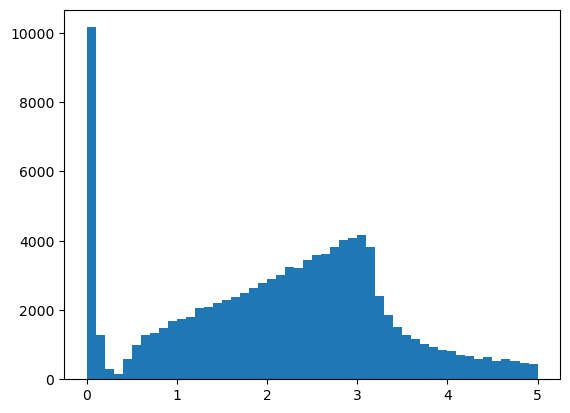

In [44]:
plt.hist(ak.flatten(ak.flatten(dr_jets)), bins=50, range=(0,5));

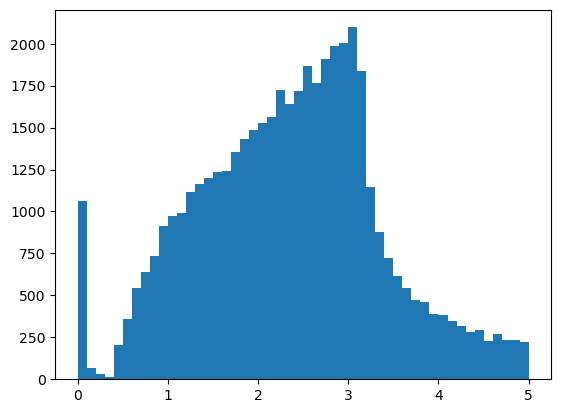

In [46]:
plt.hist(ak.flatten(ak.flatten(dr_jets_good)), bins=50, range=(0,5));

In [57]:
mask_dr_jets_good = ak.any(dr_jets_good < 0.4, axis=-1)

In [102]:
mask_dr_jets_good_photon = ak.any(dr_jets_good_photon < 0.4, axis=-1)

In [58]:
mask_dr_jets_good

<Array [[False], [False], ..., [False, False]] type='17000 * var * bool'>

In [59]:
close_photons_to_jets = selected_photons[mask_dr_jets_good]

In [104]:
close_jets_to_photon = selected_jets[mask_dr_jets_good_photon]

In [61]:
close_photons_to_jets[ak.num(close_photons_to_jets) > 0].pt

<Array [[22.1], [31.6], ..., [22.4], [66.4]] type='1166 * var * float32[par...'>

In [62]:
gen = events.GenPart

In [106]:
close_photons_to_jets_mother = gen[close_photons_to_jets.genPartIdx]

In [ ]:
mother_close_photons_to_jets_mother = gen[close_photons_to_jets_mother.genPartIdxMother]

In [69]:
np.unique(ak.flatten(mother_close_photons_to_jets_mother[ak.num(mother_close_photons_to_jets_mother)>0].pdgId))

<Array [-4124, -511, -423, -421, ..., 421, 423, 511, 4222] type='22 * int32'>

In [147]:
from collections import Counter
from particle import Particle

# Flatten PDG IDs
pdg_ids = ak.to_numpy(ak.flatten(mother_close_photons_to_jets_mother[ak.num(mother_close_photons_to_jets_mother) > 0].pdgId))

# Optional: take absolute values (merge particle/antiparticle)
pdg_ids = pdg_ids

# Count frequencies
counter = Counter(pdg_ids)

# Convert to names
labels = []
counts = []

for pdg, count in sorted(counter.items()):
    try:
        name = Particle.from_pdgid(pdg).name
    except:
        name = str(pdg)  # fallback if unknown
    
    labels.append(name)
    counts.append(count)

n = len(labels)

hist = ROOT.TH1F("h_pdg", ";Mother of matched gen particle to close jet photons;Count", n, 0, n)

for i, (label, count) in enumerate(zip(labels, counts), start=1):
    hist.SetBinContent(i, count)
    hist.GetXaxis().SetBinLabel(i, label)

# Styling
hist.LabelsOption("v")  # vertical labels

c = ROOT.TCanvas("c", "", 1000, 600)
c.SetBottomMargin(0.15)  # increase bottom margin for labels
hist.Draw("HIST")
hist.GetXaxis().SetTitleOffset(2.4)

c.SaveAs("/eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/pdg_frequency_jets_pho.png")

Warning in <TROOT::Append>: Replacing existing TH1: h_pdg (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Cutflow_dist_after_presel_update/pdg_frequency_jets_pho.png has been created


In [89]:
A = gen[gen.pdgId == 35]

In [90]:
A.pt

<Array [[40.6, 54.6], [...], ..., [182, 112]] type='17000 * var * float32[p...'>

In [95]:
def delta_r_manual_simple(obj1, obj2):
    deta = obj1.eta - obj2.eta
    dphi = np.abs(obj1.phi - obj2.phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

In [96]:
delta_r_manual_simple(A[:,0], A[:,1])

<Array [2.38, 2.11, 1.49, ..., 1.38, 0.776] type='17000 * float32[parameter...'>

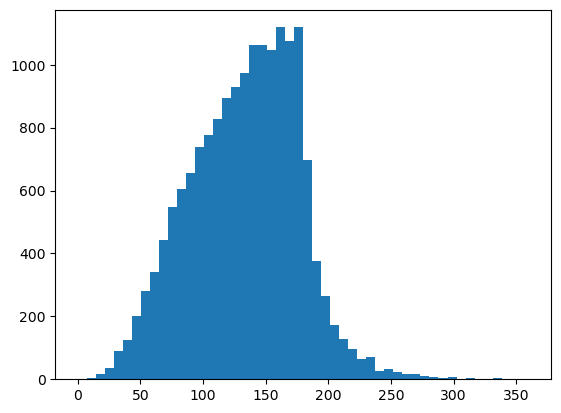

In [99]:
plt.hist(delta_r_manual_simple(A[:,0], A[:,1])*(180/np.pi), bins=50, range=(0,360));

In [107]:
close_jets_to_photon.fields

['chMultiplicity',
 'nConstituents',
 'nElectrons',
 'nMuons',
 'nSVs',
 'neMultiplicity',
 'electronIdx1',
 'electronIdx2',
 'muonIdx1',
 'muonIdx2',
 'svIdx1',
 'svIdx2',
 'hfadjacentEtaStripsSize',
 'hfcentralEtaStripSize',
 'PNetRegPtRawCorr',
 'PNetRegPtRawCorrNeutrino',
 'PNetRegPtRawRes',
 'UParTAK4RegPtRawCorr',
 'UParTAK4RegPtRawCorrNeutrino',
 'UParTAK4RegPtRawRes',
 'UParTAK4V1RegPtRawCorr',
 'UParTAK4V1RegPtRawCorrNeutrino',
 'UParTAK4V1RegPtRawRes',
 'area',
 'btagDeepFlavB',
 'btagDeepFlavCvB',
 'btagDeepFlavCvL',
 'btagDeepFlavQG',
 'btagPNetB',
 'btagPNetCvB',
 'btagPNetCvL',
 'btagPNetCvNotB',
 'btagPNetQvG',
 'btagPNetTauVJet',
 'btagUParTAK4B',
 'btagUParTAK4CvB',
 'btagUParTAK4CvL',
 'btagUParTAK4CvNotB',
 'btagUParTAK4Ele',
 'btagUParTAK4Mu',
 'btagUParTAK4QvG',
 'btagUParTAK4SvCB',
 'btagUParTAK4SvUDG',
 'btagUParTAK4TauVJet',
 'btagUParTAK4UDG',
 'btagUParTAK4probb',
 'btagUParTAK4probbb',
 'chEmEF',
 'chHEF',
 'eta',
 'hfEmEF',
 'hfHEF',
 'hfsigmaEtaEta',
 'hfsi

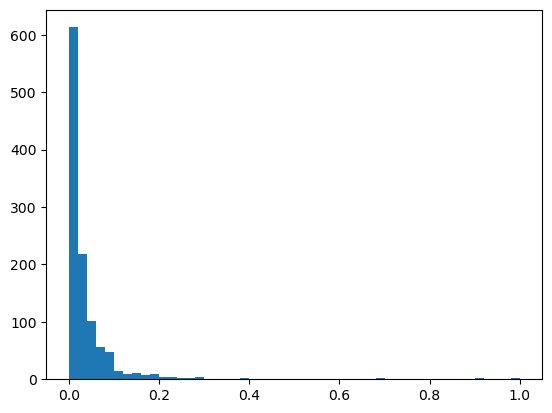

In [110]:
plt.hist(ak.flatten(close_jets_to_photon[ak.num(close_jets_to_photon) > 0].btagUParTAK4B), bins=50, range=(0,1));